In [1]:
import numpy as np
import pandas as pd
import sdeint
import tqdm
import os
import matplotlib.pyplot as plt
# import pandas as pd

In [2]:
# Parameters
N = 0.44 * 1e12  # Number of atoms
q = 0.198        # Parameter
T2 = 0.87 * 1e-3  # Relaxation time in s
g_D = 0.00177    # [pA]
Sph = 96         # Photon noise PSD [pA^2/Hz]
w0 = 2 * np.pi * 1e4  # Mean value of the Larmor in OU process
w01 = w0 * T2  # in non dimensional units
h = 50 * 1e-9    # Time step is the solver time step not the probing time!whath out
tf = 2.        # Final time in [ms]
nsteps = int(tf * 1e-3 / h)  # Number of steps in simulation
h1 = h / T2      # Time step in non-dimensional units
dc = 0.0
# dc = 0.01         # Diffusion constant of the OU process 0.01 for fluctuating
tau = 0.001
# tau=0.1
measure_every_nth = 100
meas_probing_rate = h*measure_every_nth  # in s
#TRANSFORM DATA - compute coefficients
Nq = N * q
xc = np.sqrt(2 / Nq)
yc = np.sqrt(2 / (g_D**2 * Nq))
sig_v = np.sqrt(2 * Sph / (g_D**2 * Nq * meas_probing_rate))
meas_probing_rate_unitless = meas_probing_rate/T2

# Time constant of the OU process in non-dimensional units
G = np.diag([np.sqrt(2), np.sqrt(2), np.sqrt(dc)])  # Matrix G
D = np.array([[2, 0, 0], [0, 2, 0], [0, 0, dc]])

xc2 = xc*xc
sgv2 = sig_v**2  # measurement noise variance

# Time vector in [ms] simulation
t = np.arange(0, tf/(T2*1e3), h1)
t_meas = np.arange(0, tf/(T2*1e3), meas_probing_rate_unitless)

# Initial condition (simulation)
x = np.array([0, np.sqrt(2 / (q * N)) * 0.5 * N, w0 * T2])


In [3]:
# SIMULATION
def f_x(x, t):
    f = np.zeros(3)
    f[0] += -x[0] + x[2] * x[1]
    f[1] += -x[2]*x[0] - x[1]
    # f[2] += (w01 - x[2]) / tau  # OU process
    f[2] += 0
    return f

def f_x_OU(x, t):
    f = np.zeros(3)
    f[0] += -x[0] + x[2] * x[1]
    f[1] += -x[2]*x[0] - x[1]
    f[2] += (w01 - x[2]) / tau  # OU process
    return f

def get_intrinsic_noise(dt):
    """Generates dW Wiener increment of the intrinsic noise."""
    return np.array([np.sqrt(dt),
                     np.sqrt(dt),
                     np.sqrt(dt)]) * np.random.randn(3)

def get_G(x, t):
    return np.diag([np.sqrt(2), np.sqrt(2), np.sqrt(dc)])

def step(x0, t, dt, num_steps=20, type=None):
    t_span = np.linspace(t, t + dt, num_steps)
    dW = np.array([get_intrinsic_noise(dt) for _ in t_span[1:]])
    if type==None:
        x = sdeint.itoSRI2(f=f_x,
                           G=get_G,
                           y0=x0,
                           tspan=t_span,
                           dW=dW)
    elif type=="OU":
        x = sdeint.itoSRI2(f=f_x_OU,
                           G=get_G,
                           y0=x0,
                           tspan=t_span,
                           dW=dW)
    elif type=="jump":
        if t <= 2.29879/8:
            x0[2] = 2*np.pi*9800*T2
           
        elif (t>=  2.29879/8 and t<=2.29879/4):
            x0[2] = 2*np.pi*9100.4*T2
        
        else:
            x0[2] = 2*np.pi*10000.0*T2
            
        x = sdeint.itoSRI2(f=f_x,
                           G=get_G,
                           y0=x0,
                           tspan=t_span,
                           dW=dW)
    elif type=="sine":
        x0[2] = 0.1*w01*np.sin(0.05*w01*t)+ 2*np.pi*10800.0*T2
        x = sdeint.itoSRI2(f=f_x,
                           G=get_G,
                           y0=x0,
                           tspan=t_span,
                           dW=dW)
    return x[-1]

def simulate(t_max, dt, x0, xs, num_steps=20, type=None):
    time_arr = np.arange(0, t_max, dt)
    for index, time in enumerate(tqdm.tqdm(time_arr, desc='pid:%r' % os.getpid())):
        # SIMULATION AND MEASUREMENT==============================
        x = step(x0, time, dt, num_steps, type=type)
        xs[index] = x
        x0 = x         
    return xs


In [16]:
time_arr_sim_unitless = np.arange(0, tf/(T2*1e3), h1)
xs = np.array([np.zeros_like(x) for _ in time_arr_sim_unitless])
simulate(tf/(T2*1e3), h1, x, xs)

pid:16884:   5%|▍         | 1892/40000 [00:03<01:20, 474.96it/s]


KeyboardInterrupt: 

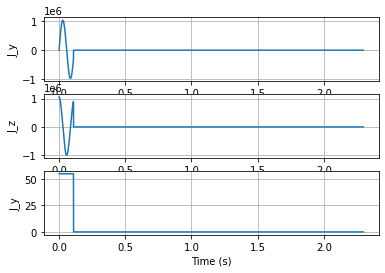

In [17]:
#Plot simulation
fig, axs = plt.subplots(3, 1)
axs[0].plot(t, xs[:,0], label="J_y")
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('J_y')
axs[0].grid(True)

axs[1].plot(t, xs[:,1], label="J_z")
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('J_z')
axs[1].grid(True)

axs[2].plot(t, xs[:,2], label="J_y")
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('J_y')
axs[2].grid(True)


# Generate noisy measurement outcomes

In [18]:
#Generate measurement outcomes
yh = []
for idx, x1_val in enumerate(xs[:, 1]):
    if idx % measure_every_nth == 0:  # Collect every nth sample
        yh.append(x1_val + sig_v * np.random.randn())  # Add noise to the measurement


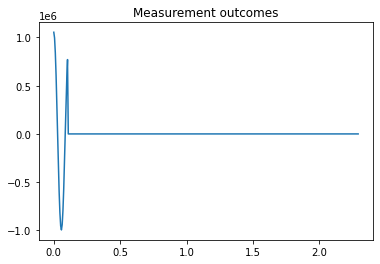

In [19]:
plt.plot(t_meas, yh)
plt.title("Measurement outcomes")
plt.show()

# EKF

In [ ]:
from scipy.integrate import solve_ivp

In [ ]:
def dP_dt(t, P, x, Q, F, dim_x):
    P_matrix = np.reshape(P, (dim_x, dim_x))
    return np.reshape(F(x,t)@ P_matrix + P_matrix@F(x,t).T + Q,dim_x**2)
    # return np.reshape(np.dot(F(x, t), np.reshape(P, (dim_x, dim_x))) +
    #                   np.dot(np.reshape(P, (dim_x, dim_x)), np.transpose(F(x, t)) + Q),
    #                   dim_x ** 2)


def F(x, t):
    # Jacobian of f
    return np.array([
        [-1, x[2], x[1]],
        [-x[2], -1, -x[0]],
        [0, 0, 0]
        # [0, 0, -1 / tau]
    ])

def F_OU(x, t):
    # Jacobian of f
    return np.array([
        [-1, x[2], x[1]],
        [-x[2], -1, -x[0]],
        [0, 0, -1 / tau]
    ])

def f_x_ekf(t, x):
    f = np.zeros(3)
    f[0] += -x[0] + x[2] * x[1]
    f[1] += -x[2] * x[0] - x[1]
    # f[2] += (w01 - x[2]) / tau  # OU process
    f[2] += 0
    return f

def f_x_OU_ekf(t, x):
    f = np.zeros(3)
    f[0] += -x[0] + x[2] * x[1]
    f[1] += -x[2] * x[0] - x[1]
    f[2] += (w01 - x[2]) / tau  # OU process
    return f

def ekf_predict(t, x, P, Q, delta_t, dim_x, type=None):
    if type == None:
        P_sol = solve_ivp(dP_dt,
                          [t, t + delta_t],
                          np.reshape(P, dim_x ** 2),
                          method='RK45',
                          dense_output=True,
                          max_step=delta_t/(measure_every_nth*20),
                          args=(x,
                                Q,
                                F,
                                dim_x))
        x_sol = solve_ivp(f_x_ekf,
                          [t, t + delta_t],
                          x,
                          method='RK45',
                          max_step=delta_t/(measure_every_nth*20),
                          dense_output=True)
    if type == "OU":
        P_sol = solve_ivp(dP_dt,
                          [t, t + delta_t],
                          np.reshape(P, dim_x ** 2),
                          method='RK45',
                          dense_output=True,
                          max_step=delta_t/(measure_every_nth*200),
                          args=(x,
                                Q,
                                F_OU,
                                dim_x))
        x_sol = solve_ivp(f_x_OU_ekf,
                      [t, t + delta_t],
                      x,
                      method='RK45',
                      max_step=delta_t/(measure_every_nth*200),
                      dense_output=True)
    
    P_temp = P_sol.sol(t + delta_t)
    x = x_sol.sol(t + delta_t)
    P = np.reshape(P_temp, (dim_x, dim_x))
    # P = 0.5 * (P + P.T)
    return x, P


def ekf_update_new(y, x, P, R_delta):
    """
    Perform one EKF update step given the measurement y.

    Args:
        y: Scalar measurement value.
        x: Current state estimate (dim_x-dimensional vector).
        P: Current state covariance matrix (dim_x x dim_x).
        R_delta: Measurement noise covariance (scalar).

    Returns:
        Updated state estimate (x) and covariance (P).
    """
    H = np.array([[0., 1., 0.]])  # Shape: (1, dim_x)

    # Compute innovation (difference between actual and predicted measurement)
    innovation = np.array([y]) - np.dot(H, x)  # Shape: (1,)

    # Innovation covariance
    S = np.dot(H, np.dot(P, H.T)) + R_delta  # Shape: (1, 1)

    # Kalman gain
    K = np.dot(P, np.dot(H.T, np.linalg.inv(S)))  # Shape: (dim_x, 1)

    # State update
    x_new = x + np.dot(K, innovation)

    P_new = (np.eye(3)-K@H)@P
    P_new = 0.5*(P_new+P_new.T)
    return x_new, P_new

In [6]:
# Kalman initialization
dw0 = 0.01
dJ = 0.01
x_current = np.array([0, 0.5 * xc * N * (1 + dJ), w0 * (1 + dw0)*T2])
P_current = np.diag([
    (0.5 * xc * N * dJ/3)**2,
    (0.5 * xc * N * dJ/3)**2,
    (w0 * T2 * dw0/3)**2
])

# Time vector in [ms] simulation
t = np.arange(0, len(xs[:, 2])) * h1
t_meas = np.arange(0, len(yh)) * meas_probing_rate_unitless

# Allocate memory
P_est = np.zeros((len(yh), 3))
x_est = np.zeros((len(yh), 3))
print(x_current, xs[0, :], "initial estimate")

for index, val in enumerate(tqdm.tqdm(t_meas, desc='pid:%r' % os.getpid())):
    x_current, P_current = ekf_update_new(yh[index], x_current, P_current, R_delta=sgv2)
    x_est[index, :] = x_current.T  # Store the state estimate (transpose if m is a row vector)
    P_est[index, :] = [P_current[0, 0], P_current[1, 1], P_current[2, 2]]
    x_current, P_current = ekf_predict(val, x_current, P_current, D, delta_t=meas_probing_rate_unitless, dim_x=3)

NameError: name 'xs' is not defined

In [12]:
# acos_est, t_rescaled_arr, phi_arr, val_arr = simple_estimator(t_meas*T2, yh/yc)
# env_est = env_detection(t_meas*T2, yh/yc)
f_l_func_fit = func_fit_approach(t_meas*T2, yh)

NameError: name 'func_fit_approach' is not defined

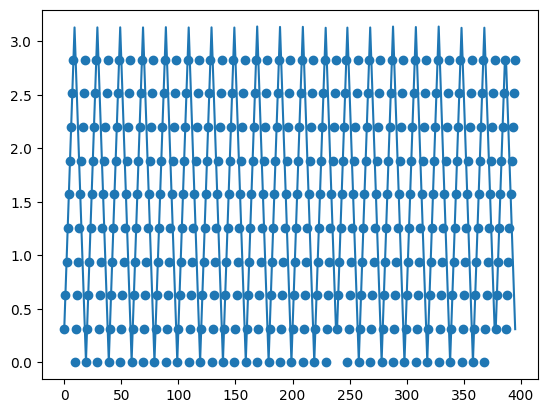

In [469]:
plt.plot(np.arange(len(t_rescaled_arr)), phi_arr)
plt.scatter(np.arange(len(t_rescaled_arr)),t_rescaled_arr*w0)

In [512]:
f_l_func_fit

[1.1140846016432675,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.3089682054292617,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.5915494309189535,
 1.4258983677008583,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.1140846016432675,
 1.3089682054292617,
 1.4941076290

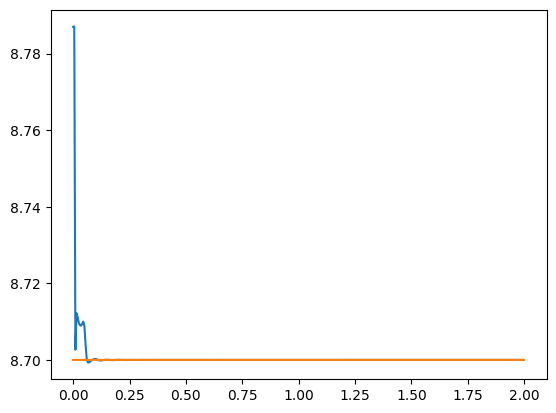

In [555]:
# Larmor frequency
f_L = xs[:, 2] / (2 * np.pi * T2 * 1e3)  # [kHz]
f_ud = (w0 * T2 + 3 * np.sqrt(dc) * np.array([-1, 1])) / (2 * np.pi * T2 * 1e3)  # 3σ bounds
#
# Plot Larmor frequency
# plt.plot(t_meas, x_est[:, 1], label='EKF')
# plt.plot(t, xs[:, 1], label='Jz')
# # plt.axhline(f_ud[0], linestyle='--', color='red', label='Lower Bound')
# # plt.axhline(f_ud[1], linestyle='--', color='green', label='Upper Bound')
# plt.xlabel('t [ms]')
# plt.ylabel('J_z')
# plt.title('Jz, OU process')
# plt.legend()
# plt.show()
# #
# plt.plot(t_meas, x_est[:, 0])
# plt.plot(t, xs[:, 0])
# plt.title('J_y')
# plt.legend()
# plt.show()

plt.plot(t_meas*T2*1e3, x_est[:, 2]/(2*np.pi))
plt.plot(t*T2*1e3, xs[:, 2]/(2*np.pi))
# plt.scatter(t_meas*T2*1e3, f_l_func_fit)
plt.show()

In [491]:
x_est[:, 2]/(2*np.pi)

array([8.787     , 8.78707411, 8.70265904, 8.71219755, 8.71116738,
       8.70968798, 8.70908528, 8.70893389, 8.7093978 , 8.70999736,
       8.70885658, 8.70407887, 8.70046737, 8.69934778, 8.6993275 ,
       8.69953864, 8.69978603, 8.69998102, 8.70013654, 8.70023259,
       8.70024058, 8.70014914, 8.69999936, 8.69988067, 8.69984351,
       8.69985884, 8.69991197, 8.69996099, 8.69999632, 8.70002554,
       8.70003136, 8.70001045, 8.69997306, 8.69994139, 8.69993023,
       8.69993813, 8.6999553 , 8.69997728, 8.69999536, 8.70000897,
       8.70001204, 8.70000501, 8.69998878, 8.69997026, 8.69995942,
       8.69995888, 8.69996551, 8.69997574, 8.69998668, 8.69999466,
       8.69999658, 8.69999363, 8.69998476, 8.69997758, 8.69997457,
       8.69997467, 8.69997748, 8.69998409, 8.69999016, 8.69999337,
       8.69999415, 8.69999225, 8.69998777, 8.69998126, 8.69997944,
       8.69998064, 8.69998219, 8.69998569, 8.69998963, 8.69999221,
       8.69999298, 8.69999162, 8.6999884 , 8.69998567, 8.69998

In [493]:
xs[:, 2]/(2*np.pi)

array([8.7, 8.7, 8.7, ..., 8.7, 8.7, 8.7])

In [535]:
f_l_func_fit

[7.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 8.223232232322323,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 8.9579995799958,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 8.208982089820898,
 9.371133711337114,
 10.0,
 10.0,
 10.0,
 10.0,
 9.65418654186542,
 8.286412864128641,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.0,
 7.4010440104401045,
 8.204152041520416,
 8.949089490894908,
 7.9552995529955295,
 7.0,
 7.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 9.38148381483815,
 8.56091560915609,
 7.759037590375904,
 7.006030060300603,
 7.6021060210602105,
 8.202382023820238,
 8.789787897878979,
 9.364593645936461,
 9.927519275192752,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 10.0,
 9.660366603666036,
 8.969999699997,
 8.292682926829269,
 7

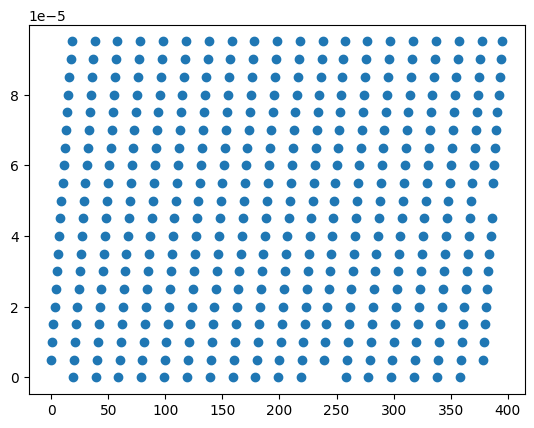

In [457]:
plt.scatter(np.arange(len(t_rescaled_arr)),t_rescaled_arr)

# Simulation time varying field

In [13]:
# dc = 0.001 # we need to change dc only because it was 0 for const field 
dc = 1e-2
tf= 1.
tau = 1e3
time_arr_sim_unitless_OU = np.arange(0, tf/(T2*1e3), h1)

xs_OU = np.array([np.zeros_like(x) for _ in time_arr_sim_unitless_OU])
simulate(tf/(T2*1e3), h1, x, xs_OU, type="OU")

get_G(x, 0)

NameError: name 'simulate' is not defined

In [566]:
h1*T2

5.0000000000000004e-08

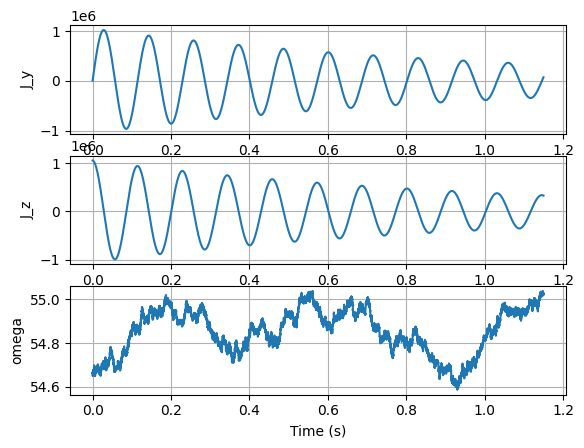

In [567]:

#Plot simulation
fig, axs = plt.subplots(3, 1)
axs[0].plot(time_arr_sim_unitless_OU, xs_OU[:,0], label="J_y")
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('J_y')
axs[0].grid(True)

axs[1].plot(time_arr_sim_unitless_OU, xs_OU[:,1], label="J_z")
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('J_z')
axs[1].grid(True)

axs[2].plot(time_arr_sim_unitless_OU, xs_OU[:,2], label="omega")
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('omega')
axs[2].grid(True)

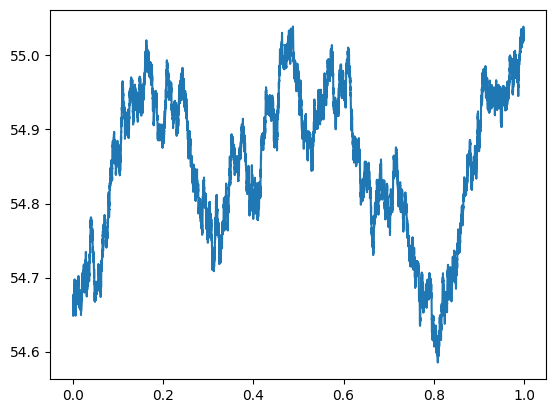

In [568]:
t_OU = np.arange(0, tf, h*1e3) #in ms
plt.plot(t_OU, xs_OU[:,2], label="J_y")

In [569]:
import pandas as pd
# Save full simulation data
OU_sim_data = pd.DataFrame({
    "time_sim": t_OU,
    "J_y_sim": xs_OU[:, 0]/xc,
    "J_z_sim": xs_OU[:, 1]/xc,
    "omega_sim": xs_OU[:, 2]/T2
})
OU_sim_data.to_csv("C:/Users/Klaudia/Documents/CD_EKF/OU_simulation_dc_%f_tau_%dtau" %(dc, tau))

In [570]:
#Generate measurement outcomes
measure_every_nth = 10
meas_probing_rate= h*measure_every_nth
meas_probing_rate_unitless = meas_probing_rate/T2

yh = []
x_sim_OU_meas_freq = []

for idx, x1_val in enumerate(xs_OU[:, 1]):
    if idx % measure_every_nth == 0:  # Collect every nth sample
        yh.append(x1_val + sig_v * np.random.randn())
        x_sim_OU_meas_freq.append(xs_OU[idx,:])

x_sim_OU_meas_freq = np.array(x_sim_OU_meas_freq)


In [668]:
# def func_fit_approach(t, yh):
#     f_L_est = [] 
#     
#     def model(t, f_L):
#         return g_D*(N/2)*np.exp(-t/T2)*np.cos(2*np.pi*f_L*1e3*t)*yc
#     
#     for index, y in enumerate(yh):
#         f_L_vals= np.linspace(8.7, 8.8, 10000)
#         errors = np.array([np.abs(model(t[index], f_L)-y) for f_L in f_L_vals])
#         f_L_best = f_L_vals[np.argmin(errors)]
#         f_L_est.append(f_L_best)
#     print(errors)
#     return f_L_est

import numpy as np

def func_fit_approach(t, yh, window_size=10):
    f_L_est = np.full_like(t, np.nan, dtype=np.float64)  # Preallocate with NaNs

    def model(t_window, f_L):
        return g_D * (N / 2) * np.exp(-t_window / T2) * np.cos(2 * np.pi * f_L * 1e3 * t_window) * yc

    half_win = window_size // 2

    for i in range(len(t)):
        # Define window bounds
        start = max(0, i - half_win)
        end = min(len(t), i + half_win + 1)

        t_window = t[start:end]
        y_window = yh[start:end]

        f_L_vals = np.linspace(8.69, 8.77, 1000)
        errors = []

        for f_L in f_L_vals:
            y_model = model(t_window, f_L)
            err = np.sum(np.abs(y_model - y_window) ** 2)
            errors.append(err)

        min_index = np.argmin(errors)
        f_L_best = f_L_vals[np.argmin(errors)]
        f_L_est[i] = f_L_best
        # print(model(t_window[0], f_L_best), y_window)


    return f_L_est


In [ ]:
# f_l_func_fit = func_fit_approach(t_meas, yh)


In [ ]:
f_l_func_fit

In [573]:
def simple_estimator(time, yh):
    fl_acos = []
    t_rescaled_arr = []
    phi_arr = []
    val_arr = []
    n = 0  # Start with n=0
    last_phase = None
    fl = 0

    for index, y in enumerate(yh):
        t = time[index]
        t_rescaled = (w0*t % (np.pi))/w0
        # t_rescaled = (w01*t % (2*np.pi))/w01

        if t > 0:
            val = (y / g_D) * (2 / N) * np.exp(t / T2)
            val_arr.append(val)
            if abs(val) <= 1:
                phi = np.arccos(val)  
                omega = phi / t_rescaled  # rad/s
                fL = omega / (2 * np.pi)  # Hz
                fl_acos.append(fL / 1e3)  # kHz
                print('index', index, 'phi', phi, 'n', n, 'f', fl/1e3)
                t_rescaled_arr.append(t_rescaled)
                phi_arr.append(phi)
                

            elif val>1:
                fl_acos.append(0)
            elif val<-1:
                fl_acos.append(np.pi)
        else:
            fl_acos.append(np.nan)

    return np.array(fl_acos), np.array(t_rescaled_arr), np.array(phi_arr), np.array(val_arr)


In [574]:
from scipy.signal import hilbert

def env_detection(time, yh):
    time = np.asarray(time)
    yh = np.asarray(yh)

    if time.shape[0] != yh.shape[0]:
        raise ValueError("`time` and `yh` must have the same length.")

    # Hilbert transform
    analytic_signal = hilbert(yh)
    phase = np.unwrap(np.angle(analytic_signal))  # unwrap phase

    # Differentiate phase with respect to time
    dphi_dt = np.gradient(phase, time)  # angular frequency in rad/s
    freq_hz = dphi_dt / (2 * np.pi)     # Hz

    return freq_hz / 1e3  # return in kHz


In [645]:
from scipy.signal import get_window
from scipy.fft import fft, fftfreq

def sliding_fft_freq_estimate(t, yh, window_size=128, fs=1e6):  # fs in Hz
    n = len(yh)
    half_win = window_size // 2
    freqs = fftfreq(window_size, d=1/fs)
    freqs = freqs[:window_size//2]  # Only positive freqs

    f_L_est = np.full(n, np.nan)

    for i in range(n):
        start = max(0, i - half_win)
        end = min(n, i + half_win)

        segment = yh[start:end]

        # Pad if needed
        if len(segment) < window_size:
            segment = np.pad(segment, (0, window_size - len(segment)), mode='constant')

        windowed = segment * get_window("hann", window_size)
        spectrum = np.abs(fft(windowed))[:window_size//2]
        peak_idx = np.argmax(spectrum)
        f_peak = freqs[peak_idx]

        f_L_est[i] = f_peak / 1e3  # convert to kHz

    return f_L_est


In [575]:
# Kalman initialization
dw0 = 0.01
dJ = 0.01
dc = dc
D_OU = get_G(x,0)@get_G(x, 0).T
x_current_OU = np.array([0, 0.5 * xc * N * (1 + dJ), w0 * (1 + dw0)*T2])
P_current_OU = np.diag([
    (0.5 * xc * N * dJ/3)**2,
    (0.5 * xc * N * dJ/3)**2,
    (w0 * T2 * dw0/3)**2
])

# Time vector in [ms] simulation
t_OU = np.arange(0, len(xs_OU[:, 2])) * h1
t_meas_OU = np.arange(0, len(yh)) * meas_probing_rate_unitless

# Allocate memory
P_est_OU = np.zeros((len(yh), 3))
x_est_OU = np.zeros((len(yh), 3))

print(x_current_OU, xs_OU[0, :], "initial estimate")
print(D_OU)

for index, val in enumerate(tqdm.tqdm(t_meas_OU, desc='pid:%r' % os.getpid())):
    x_current_OU, P_current_OU = ekf_update_new(yh[index], x_current_OU, P_current_OU, R_delta=sgv2)
    x_est_OU[index, :] = x_current_OU.T  
    P_est_OU[index, :] = [P_current_OU[0, 0], P_current_OU[1, 1], P_current_OU[2, 2]]
    # x_current_OU, P_current_OU = ekf_predict(val, x_current_OU, P_current_OU, D_OU, delta_t=meas_probing_rate_unitless, dim_x=3)
    x_current_OU, P_current_OU = ekf_predict(val, x_current_OU, P_current_OU, D_OU, delta_t=meas_probing_rate_unitless, dim_x=3, type="OU")

[0.00000000e+00 1.06463348e+06 5.52103493e+01] [3.31129862e+03 1.05402684e+06 5.46613690e+01] initial estimate
[[2.   0.   0.  ]
 [0.   2.   0.  ]
 [0.   0.   0.01]]


pid:73496: 100%|██████████| 2000/2000 [17:08<00:00,  1.94it/s]


In [669]:
acos_est = func_fit_approach(t_meas_OU*1e-3, yh, window_size=1)
# env_est = env_detection(t_meas_OU*1e-3, yh/yc)
# fft_est = func_fit_approach(t_meas_OU*1e-3, yh, window_size=50)


# len(yh)
# print(yh)
# print(g_D*(N/2)*np.exp(-t_meas_OU*1e-3/T2)*np.cos(2*np.pi*8.7*1e3*t_meas_OU*1e-3)*yc)

In [626]:
#Save meas outcomes and dummy estimators

OU_sim_data = pd.DataFrame({
    "time_meas": t_meas_OU*T2,
    "y": yh/yc,
    "acos_estimator": acos_est,
    'Hilbert transform': env_est
})
OU_sim_data.to_csv("C:/Users/Klaudia/Documents/CD_EKF/OU_meas_dc_%f_tau_%dtau" %(dc, tau))

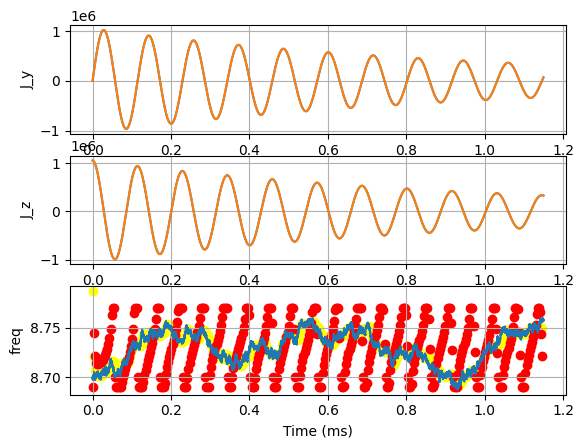

In [671]:
#Plot simulation
fig, axs = plt.subplots(3, 1)
axs[0].plot(t_OU, xs_OU[:,0], label="J_y")
axs[0].plot(t_meas_OU, x_est_OU[:, 0], label="EKF")
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('J_y')
axs[0].grid(True)

axs[1].plot(t_OU, xs_OU[:,1], label="J_z")
axs[1].plot(t_meas_OU, x_est_OU[:, 1], label="EKF")
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('J_z')
axs[1].grid(True)

axs[2].plot(t_OU, xs_OU[:,2]/(2*np.pi), label="freq")
plt_every_nth = 5
axs[2].scatter(t_meas_OU[::plt_every_nth], x_est_OU[::plt_every_nth, 2]/(2*np.pi), label="EKF", c='yellow')
axs[2].scatter(t_meas_OU[::plt_every_nth], acos_est[::plt_every_nth], label="simple", c='r')
# axs[2].scatter(t_meas_OU[::plt_every_nth], env_est[::plt_every_nth], label="env")
# axs[2].scatter(t_meas_OU[::plt_every_nth], fft_est[::plt_every_nth], label="fft")
axs[2].set_xlabel('Time (ms)')
axs[2].set_ylabel('freq')
# axs[2].set_ylim(8.65, 8.80)

# axs[2].set_xlim(0.0,0.05)
# axs[2].legend()
axs[2].grid(True)

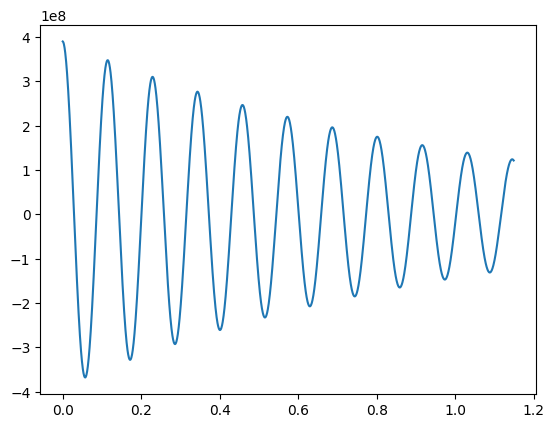

In [579]:
plt.plot(t_meas_OU, yh/yc)
# plt.xlim(0,0.2)


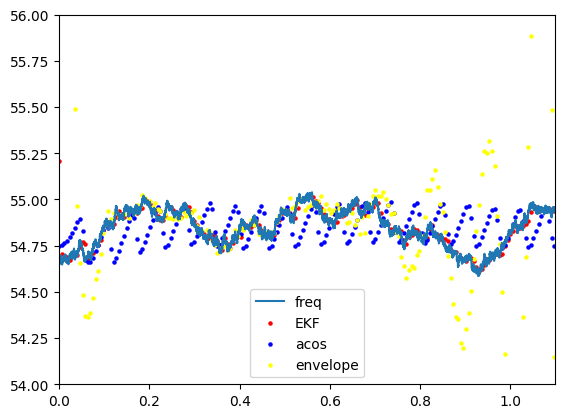

In [661]:
plt.plot(t_OU, xs_OU[:,2], label="freq")
plt.scatter(t_meas_OU[0:10000:10], x_est_OU[0:10000:10, 2], label="EKF", s=5, c='r')
plt.scatter(t_meas_OU[::10], np.array(acos_est[::10])*2*np.pi, label="acos", s=5, c='blue')
plt.scatter(t_meas_OU[::10], env_est[::10]*2*np.pi, label="envelope", s=5, c='yellow')
plt.xlim(0,1.1)
plt.ylim(54,56)
plt.legend()

In [ ]:
plt.plot(t_meas_OU[10:1000], x_est_OU[10:1000, 2], label="EKF")


In [ ]:
OU_EKF_data = pd.DataFrame({
    "time": t_meas_OU*T2,
    "J_y_EKF": x_est_OU[:, 0]/xc,
    "J_z_EKF": x_est_OU[:, 1]/xc,
    "omega_EKF": x_est_OU[:, 2]/T2,
    "P_J_y": P_est_OU[:, 0]/xc2,
    "P_J_z": P_est_OU[:, 1]/xc2,
    "P_omega": P_est_OU[:, 2]/T2**2,
    "J_y": x_sim_OU_meas_freq[:, 0]/xc,
    "J_z": x_sim_OU_meas_freq[:, 1]/xc,
    "omega": x_sim_OU_meas_freq[:, 2]/T2
})
OU_EKF_data.to_csv("C:/Users/Klaudia/Documents/CD_EKF/OU_EKF_RELAXATION_dc_%f_tau_%f_delta_%f" %(dc, tau, meas_probing_rate))

In [ ]:
plt.plot(t, xs_OU[:,2], label="freq")
plt.plot(t_meas_OU, x_est_OU[:, 2], label="EKF", color='r')
plt.grid(True)

# Jump Simulation

In [24]:
dc = 0.0
time_arr_sim_unitless = np.arange(0, tf/(T2*1e3), h1)
xs = np.array([np.zeros_like(x) for _ in time_arr_sim_unitless])
simulate(tf/(T2*1e3), h1, x, xs, type="jump")

pid:16884: 100%|██████████| 40000/40000 [01:27<00:00, 455.59it/s]


array([[ 3.24507955e+03,  1.05402693e+06,  5.35704379e+01],
       [ 6.48976903e+03,  1.05395146e+06,  5.35704379e+01],
       [ 9.73405427e+03,  1.05386594e+06,  5.35704379e+01],
       ...,
       [-1.04413719e+05, -1.71402942e+04,  5.46637122e+01],
       [-1.04461130e+05, -1.68112575e+04,  5.46637122e+01],
       [-1.04507395e+05, -1.64821153e+04,  5.46637122e+01]])

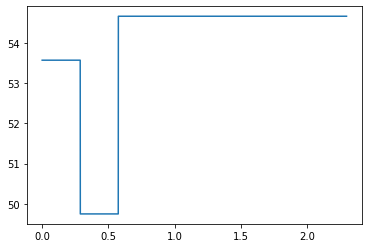

In [25]:
plt.plot(time_arr_sim_unitless, xs[:,2])
plt.show()

In [26]:
measure_every_nth = 10
meas_probing_rate= h*measure_every_nth
meas_probing_rate_unitless = meas_probing_rate/T2
yh = []
x_sim_jump_meas_freq = []
for idx, x1_val in enumerate(xs[:, 1]):
    if idx % measure_every_nth == 0:  # Collect every nth sample
        yh.append(x1_val + sig_v * np.random.randn())
        x_sim_jump_meas_freq.append(xs[idx,:])

x_sim_jump_meas_freq = np.array(x_sim_jump_meas_freq)# Add noise to the measurement

In [34]:
# Kalman initialization
dw0 = 0.01
dJ = 0.01
# dc = 0.01 #dc=1e7
# dc = 0.1 #dc=1e8
dc=1.0 #dc=1e9


x_current = np.array([0, 0.5 * xc * N * (1 + dJ), w0 * (1 + dw0)*T2])
P_current = np.diag([
    (0.5 * xc * N * dJ/3)**2,
    (0.5 * xc * N * dJ/3)**2,
    (w0 * T2 * dw0/3)**2
])
D = get_G(x_current, t)@get_G(x_current, t).T
# Time vector in [ms] simulation
t = np.arange(0, len(xs[:, 2])) * h1
t_meas = np.arange(0, len(yh)) * meas_probing_rate_unitless

# Allocate memory
P_est = np.zeros((len(yh), 3))
x_est = np.zeros((len(yh), 3))
print(x_current, xs[0, :], "initial estimate")

for index, val in enumerate(tqdm.tqdm(t_meas, desc='pid:%r' % os.getpid())):
    x_current, P_current = ekf_update_new(yh[index], x_current, P_current, R_delta=sgv2)
    x_est[index, :] = x_current.T  # Store the state estimate (transpose if m is a row vector)
    P_est[index, :] = [P_current[0, 0], P_current[1, 1], P_current[2, 2]]
    x_current, P_current = ekf_predict(val, x_current, P_current, D, delta_t=meas_probing_rate_unitless, dim_x=3)

[0.00000000e+00 1.06463348e+06 5.52103493e+01] [3.24507955e+03 1.05402693e+06 5.35704379e+01] initial estimate


pid:16884: 100%|██████████| 4000/4000 [03:35<00:00, 18.56it/s]


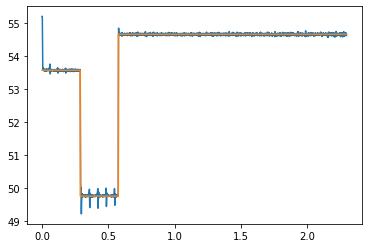

In [35]:

plt.plot(t_meas, x_est[:, 2])
plt.plot(time_arr_sim_unitless, xs[:, 2])
# plt.ylim(53.55, 53.60)
plt.show()

In [41]:
jump_EKF_data = pd.DataFrame({
    "time": t_meas*T2,
    "J_y_EKF": x_est[:, 0]/xc,
    "J_z_EKF": x_est[:, 1]/xc,
    "omega_EKF": x_est[:, 2]/T2,
    "P_J_y": P_est[:, 0]/xc2,
    "P_J_z": P_est[:, 1]/xc2,
    "P_omega": P_est[:, 2]/T2**2,
    "J_y": x_sim_jump_meas_freq[:, 0]/xc,
    "J_z": x_sim_jump_meas_freq[:, 1]/xc,
    "omega": x_sim_jump_meas_freq[:, 2]/T2
})
jump_EKF_data.to_csv("C:/Users/Klaudia\Downloads\Data_March2026/jump_EKF_dc_%f_tau_%f_delta_%f" %(dc, tau, meas_probing_rate))

# Sine signal

In [19]:
dc = 0.0
tf=2.0

In [20]:
time_arr_sim_unitless = np.arange(0, tf/(T2*1e3), h1)
xs_sine = np.array([np.zeros_like(x) for _ in time_arr_sim_unitless])
simulate(tf/(T2*1e3), h1, x, xs_sine, type="sine")

pid:1192: 100%|██████████| 40000/40000 [01:20<00:00, 496.05it/s]


array([[ 3.57630951e+03,  1.05402589e+06,  5.90368091e+01],
       [ 7.15210079e+03,  1.05394712e+06,  5.90376678e+01],
       [ 1.07275398e+04,  1.05385627e+06,  5.90385265e+01],
       ...,
       [-6.16185959e+04, -8.60294488e+04,  5.90342332e+01],
       [-6.19065860e+04, -8.58149835e+04,  5.90350918e+01],
       [-6.21937081e+04, -8.55994762e+04,  5.90359505e+01]])

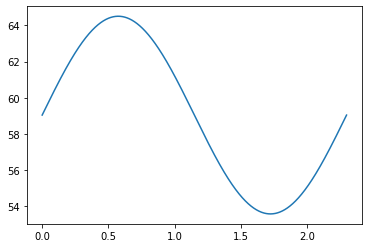

In [21]:
plt.plot(time_arr_sim_unitless, xs_sine[:, 2])

In [23]:
xs_sine[:,1]

array([1054025.88768817, 1053947.12468175, 1053856.27472042, ...,
        -86029.44876066,  -85814.98354339,  -85599.47619122])

In [24]:
measure_every_nth = 10
meas_probing_rate= h*measure_every_nth
meas_probing_rate_unitless = meas_probing_rate/T2
yh_sine = []
x_sim_sin_meas_freq = []
for idx, x1_val in enumerate(xs_sine[:, 1]):
    if idx % measure_every_nth == 0:  # Collect every nth sample
        yh_sine.append(x1_val + sig_v * np.random.randn())
        x_sim_sin_meas_freq.append(xs_sine[idx,:])

x_sim_sin_meas_freq = np.array(x_sim_sin_meas_freq)

In [32]:
# Kalman initialization
# dw0 = 0.01
dw0 = 1.1
dJ = 0.01
# dc = 0.0001

dc = 0.01 #dc=1e7
# dc = 0.1 #dc=1e8
# dc=1.0 #dc=1e9


x_current = np.array([0, 0.5 * xc * N * (1 + dJ), w0 * (1 + dw0)*T2])
P_current = np.diag([
    (0.5 * xc * N * dJ/3)**2,
    (0.5 * xc * N * dJ/3)**2,
    (w0 * T2 /3)**2
])
D = get_G(x_current, t)@get_G(x_current, t).T
# Time vector in [ms] simulation
t = np.arange(0, len(xs_sine[:, 2])) * h1
t_meas = np.arange(0, len(yh_sine)) * meas_probing_rate_unitless

# Allocate memory
P_est = np.zeros((len(yh_sine), 3))
x_est = np.zeros((len(yh_sine), 3))
print(x_current, xs_sine[0, :], "initial estimate")

for index, val in enumerate(tqdm.tqdm(t_meas, desc='pid:%r' % os.getpid())):
    x_current, P_current = ekf_update_new(yh_sine[index], x_current, P_current, R_delta=sgv2)
    x_est[index, :] = x_current.T  # Store the state estimate (transpose if m is a row vector)
    P_est[index, :] = [P_current[0, 0], P_current[1, 1], P_current[2, 2]]
    x_current, P_current = ekf_predict(val, x_current, P_current, D, delta_t=meas_probing_rate_unitless, dim_x=3)

[0.00000000e+00 1.06463348e+06 1.14793796e+02] [3.57630951e+03 1.05402589e+06 5.90368091e+01] initial estimate


pid:1192: 100%|██████████| 4000/4000 [09:19<00:00,  7.15it/s]


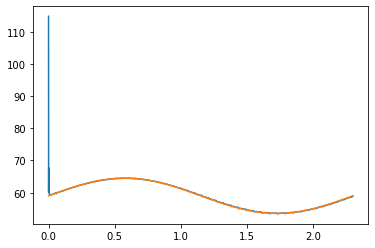

In [33]:
plt.plot(t_meas, x_est[:, 2])
plt.plot(t, xs_sine[:, 2])
# plt.ylim(50,60)
plt.show()

In [34]:
sin_EKF_data = pd.DataFrame({
    "time": t_meas*T2,
    "J_y_EKF": x_est[:, 0]/xc,
    "J_z_EKF": x_est[:, 1]/xc,
    "omega_EKF": x_est[:, 2]/T2,
    "P_J_y": P_est[:, 0]/xc2,
    "P_J_z": P_est[:, 1]/xc2,
    "P_omega": P_est[:, 2]/T2**2,
    "J_y": x_sim_sin_meas_freq[:, 0]/xc,
    "J_z": x_sim_sin_meas_freq[:, 1]/xc,
    "omega": x_sim_sin_meas_freq[:, 2]/T2
})
# sin_EKF_data.to_csv("C:/Users/Klaudia/Documents/CD_EKF/sin_EKF_dc_%f_tau_%f_delta_%f_new1" %(dc, tau, meas_probing_rate))
sin_EKF_data.to_csv("C:/Users/Klaudia\Downloads\Data_March2026/sin_EKF_dc_%f_tau_%f_delta_%f_new1" %(dc, tau, meas_probing_rate))


In [ ]:
len(x_sim_sin_meas_freq)

In [ ]:
len(x_est)